# Déploiement du modèle GAN 1D (Reconstruction de Signaux)
Ce notebook exécute le pipeline complet décrit dans le plan d'action de l'étude (Phase 1 à 5).
Pour garantir que ce test puisse s'exécuter sur un ordinateur modeste, les calculs sont limités temporellement (réseau minimal, peu d'epochs, petites fenêtres de convolution). Le code du modèle est structuré dans le dossier `src/` créé à cet effet.

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Paramètres pour entraînement complet (optimisé GPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {DEVICE}")

WINDOW_SIZE = 512       # Fenêtre plus grande pour capturer plusieurs cycles (10 à 15 cycles)
EPOCHS = 100            # L'entraînement des GAN nécessite de la patience
BATCH_SIZE = 64         # Batch plus important pour stabiliser WGAN-GP et maximiser les tensor threads
NUM_SAMPLES = 5000      # Plus d'échantillons auto-supervisés par epoch pour mieux généraliser

# Chargement du fichier exporté précédemment
fichier_entree = 'signaux_entree_dataset.pt'

if os.path.exists(fichier_entree):
    dataset_tensor = torch.load(fichier_entree)
    print(f"Chargement réussi. Shape: {dataset_tensor.shape}")
else:
    print(f"Erreur : Le fichier '{fichier_entree}' n'existe pas. Veuillez exécuter 'generation_signaux.ipynb' auparant.")

Chargement réussi. Shape: torch.Size([3, 5000])


C:\Users\colle\AppData\Local\Temp\ipykernel_13352\910153652.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset_tensor = torch.load(fichier_entree)


## Pipeline de données, Modélisation et Apprentissage (Phases 1-4)
L'étape de constitution d'un Dataset valide et l'entraînement sont réalisés. Le modèle (`U-Net` pour le générateur et `PatchGAN` pour le discriminateur) subit l'entraînement avec WGAN-GP.

In [ ]:
import sys
import copy
sys.path.append('.')

from src.dataset import SignalDataset
from src.networks import Generator, Discriminator
from src.train import train_gan

# 1. Dataset Initialization
print("Préparation du dataset (extraction d'échantillons valides et auto-supervision)...")
dataset = SignalDataset(dataset_tensor, window_size=WINDOW_SIZE, num_samples=NUM_SAMPLES)

# 2. Network Instantiation
gen = Generator(in_channels=2, out_channels=1, features=8)  # Très petit réseau
disc = Discriminator(in_channels=1, features=4)

# 3. Training Loop
print("Démarrage de l'entraînement auto-supervisé local...")
# Use optimal updates for WGAN (D=5 updates for 1 G update)
trained_generator = train_gan(
    dataset=dataset, 
    generator=gen, 
    discriminator=disc, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    d_updates=5, 
    g_updates=1,
    device=DEVICE
)

Préparation du dataset (extraction d'échantillons valides et auto-supervision)...
Démarrage de l'entraînement auto-supervisé local...
Starting training on cpu for 1 epochs...
[Epoch 1/1] [Batch 0/25] [D loss: 6.6403] [G loss: 71.9650] (L1: 0.6793, Spec: 3.8808)
[Epoch 1/1] [Batch 12/25] [D loss: 6.2484] [G loss: 74.6756] (L1: 0.7060, Spec: 3.9131)
[Epoch 1/1] [Batch 24/25] [D loss: 5.8815] [G loss: 80.0916] (L1: 0.7599, Spec: 3.9414)
Training finished.


## Phase d'Inférence (Phase 5)
Application d'une fenêtre temporelle glissante sur le signal amputé. Le réseau U-Net remplace petit à petit les trous (`NaN`).

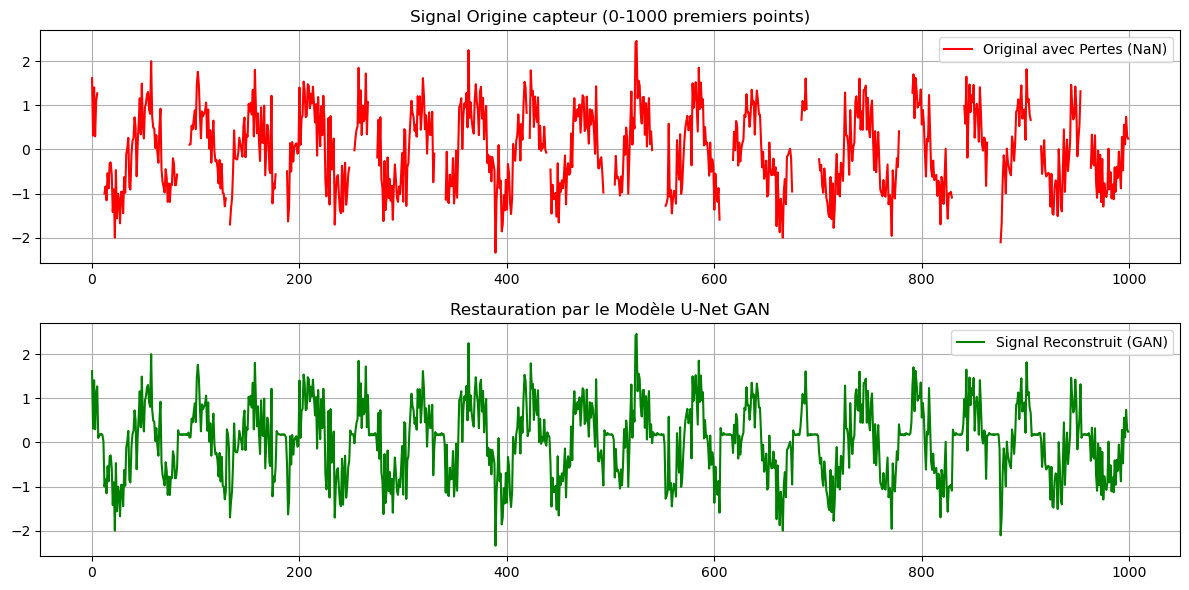

In [ ]:
from src.inference import reconstruct_signal

# Test sur le SIGNAL n°1 (index 0) du tenseur d'origine (qui contient les `NaN`)
original_signal_with_nans = dataset_tensor[0].clone()

reconstructed = reconstruct_signal(
    generator=trained_generator, 
    single_signal=original_signal_with_nans, 
    window_size=WINDOW_SIZE, 
    device=DEVICE
)

# Plot section (zoom de 0 à 1000 points sur les 5000 pour voir les détails)
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
# Plotting sans interpoler les NaN -> des "trous" physiques apparaissent
plt.plot(original_signal_with_nans.numpy()[:1000], label='Original avec Pertes (NaN)', color='red')
plt.title("Signal Origine capteur (0-1000 premiers points)")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
# Signal réparé par le GAN (les NaN sont tous remplis)
plt.plot(reconstructed.numpy()[:1000], label='Signal Reconstruit (GAN)', color='green')
plt.title("Restauration par le Modèle U-Net GAN")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()